## Visualizing comparisons

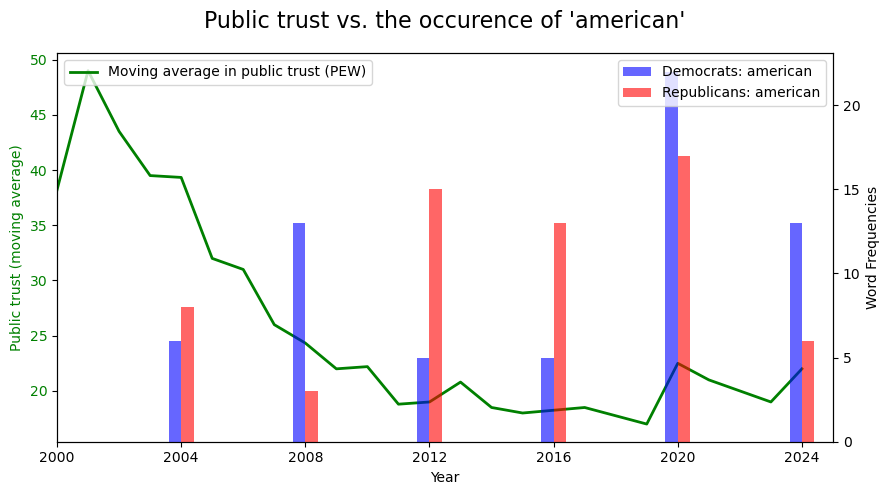

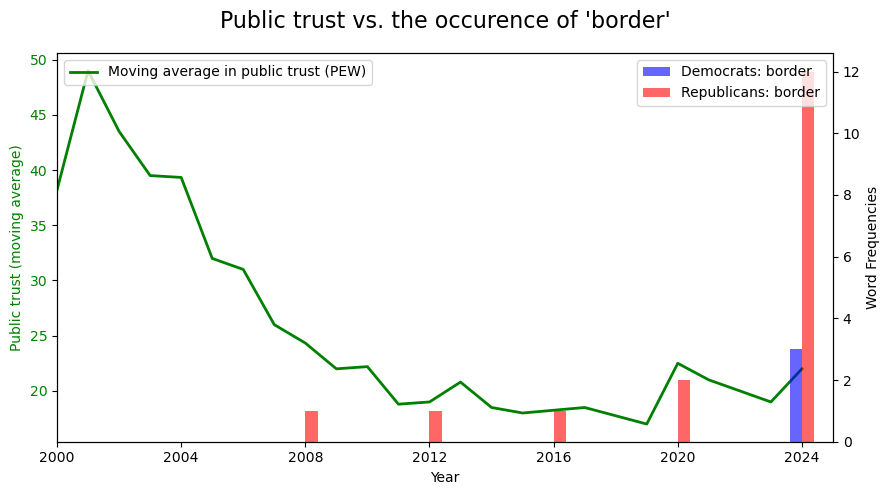

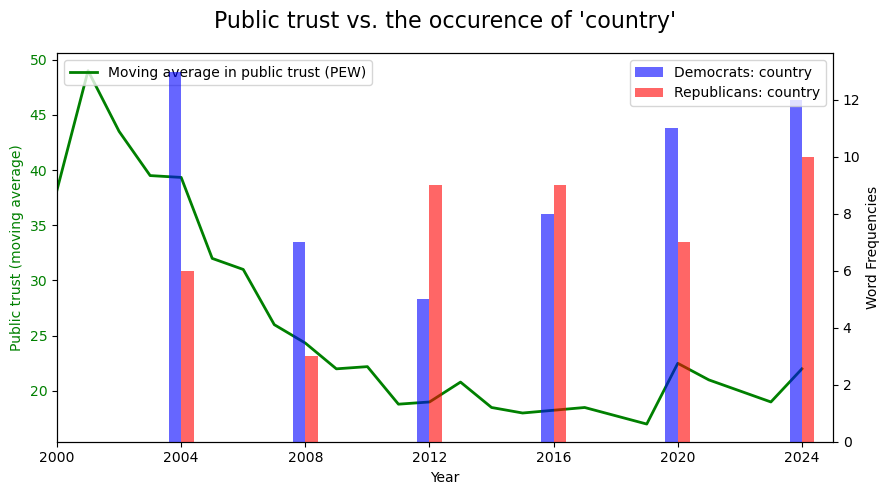

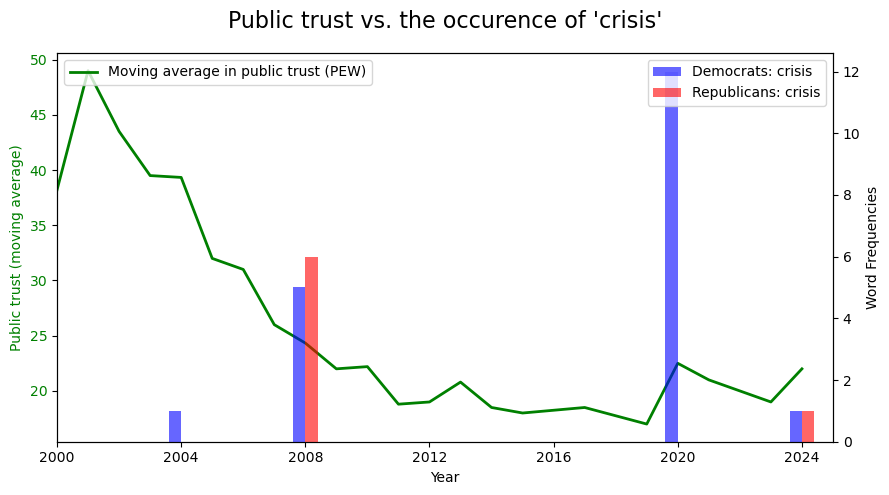

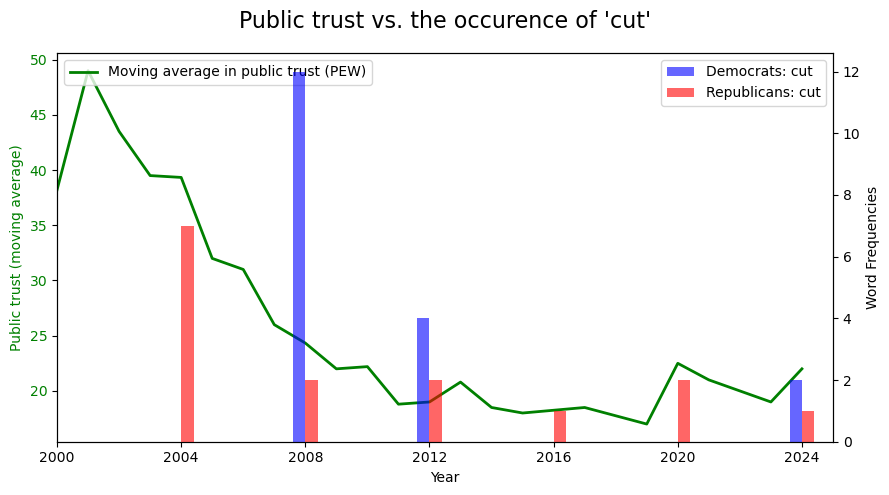

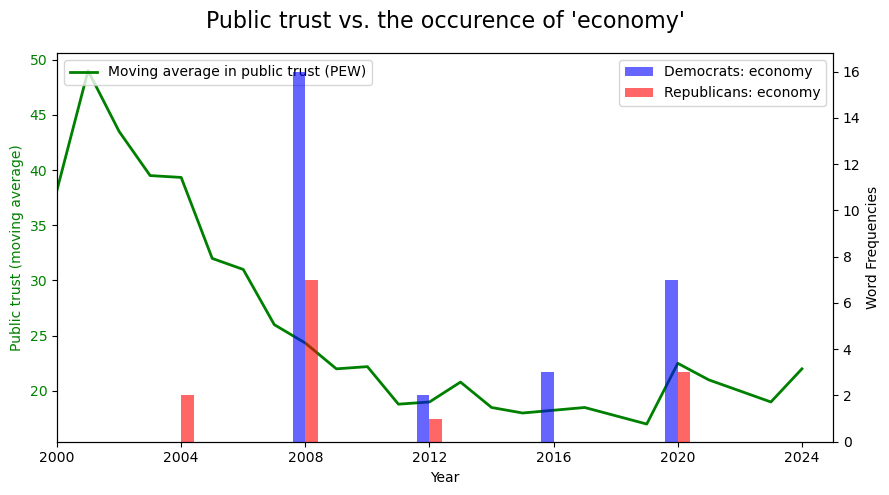

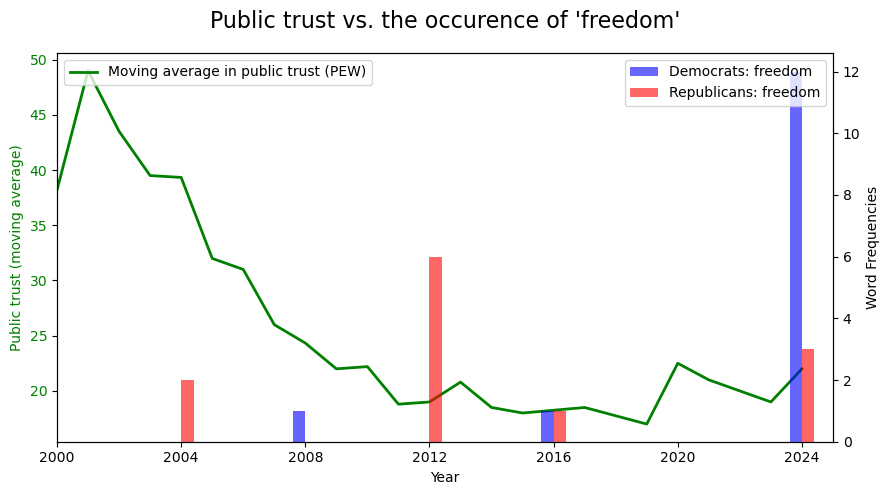

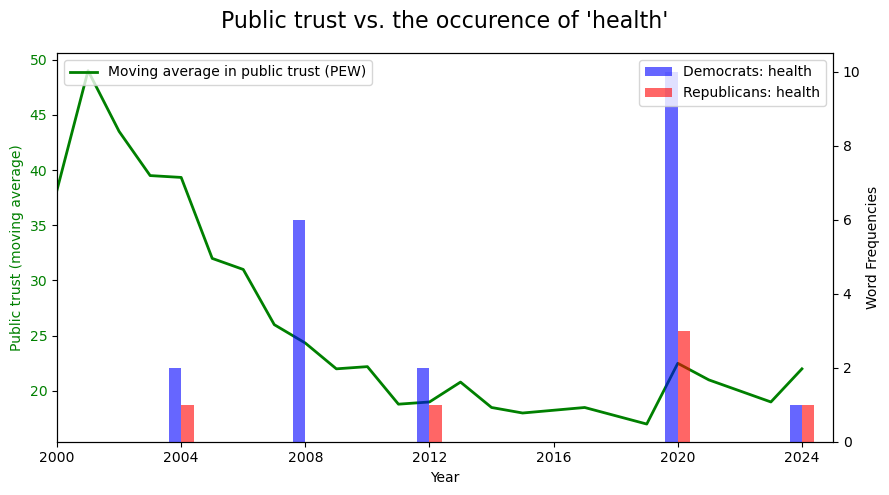

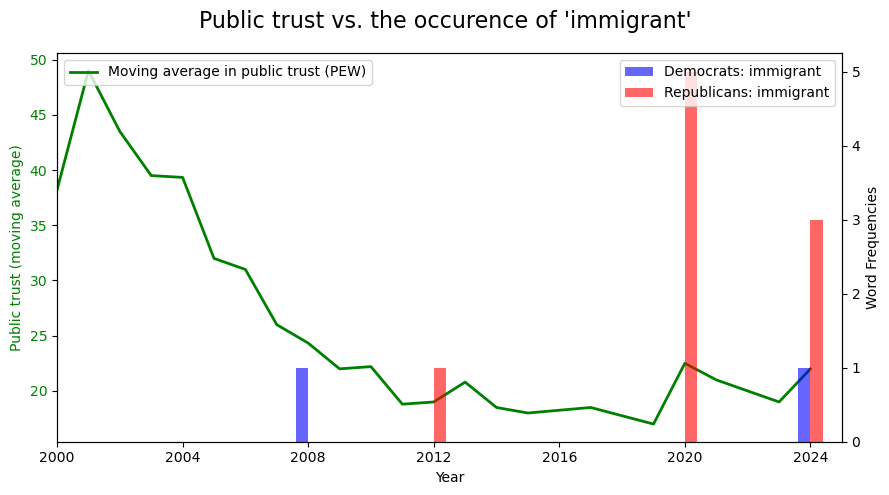

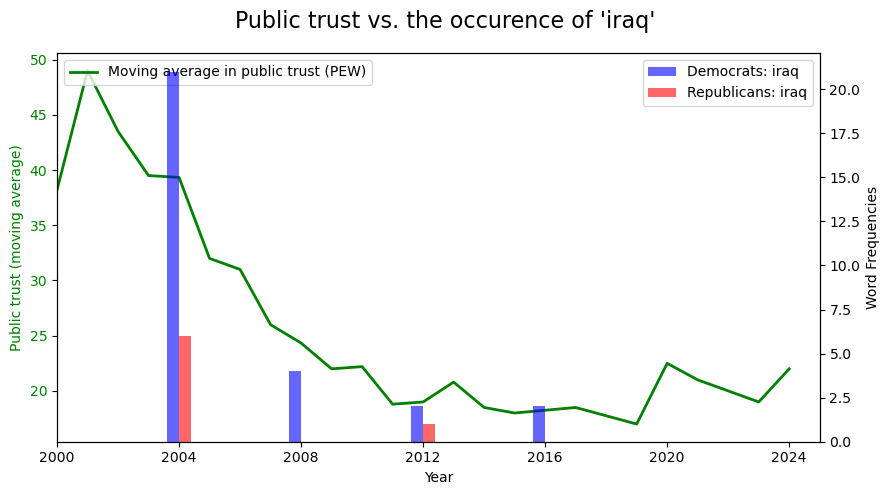

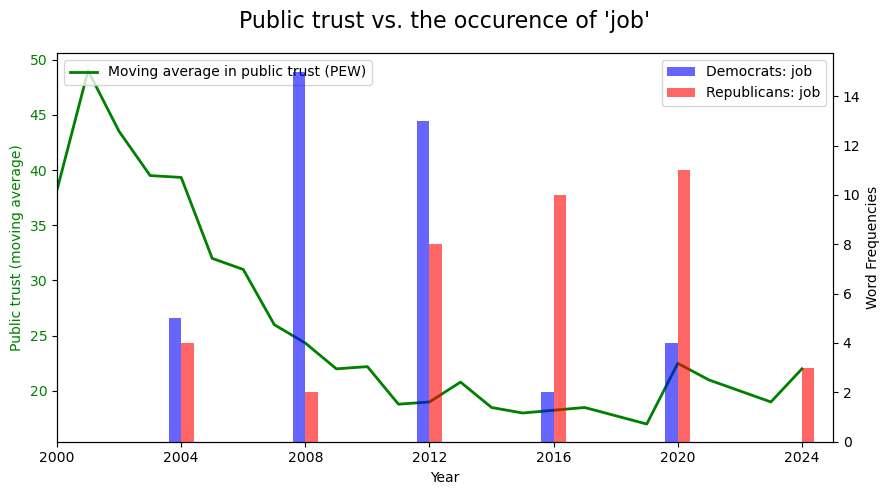

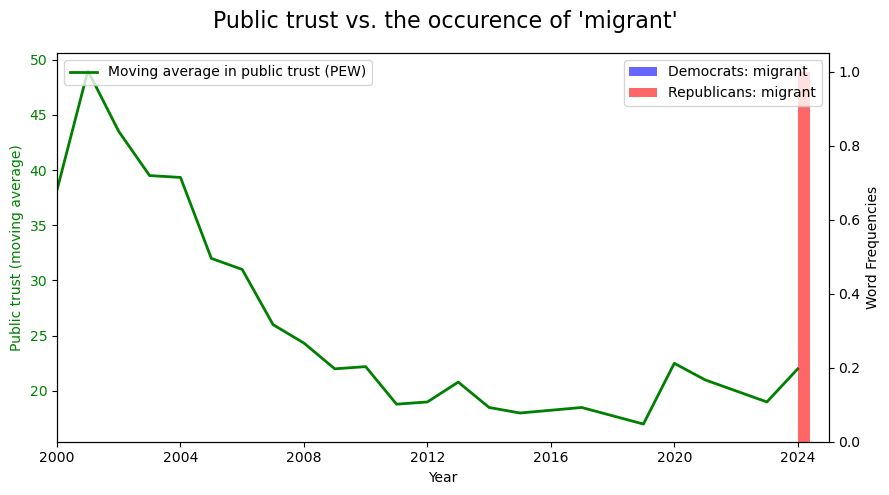

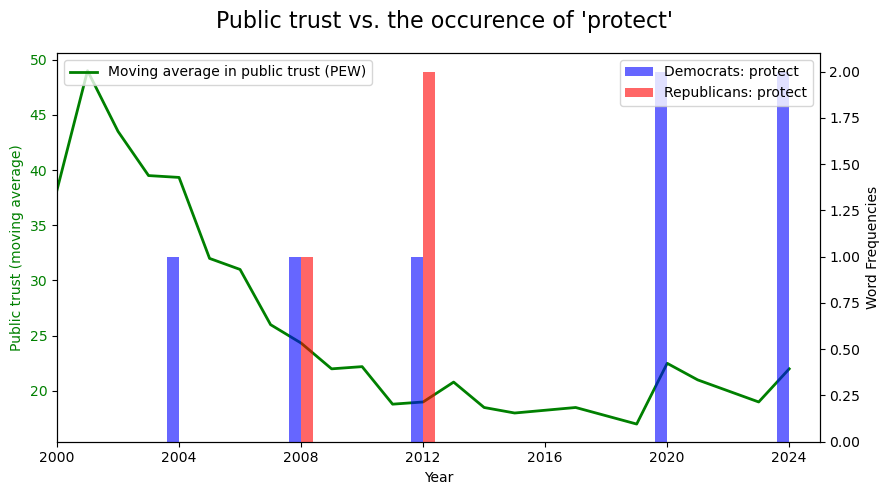

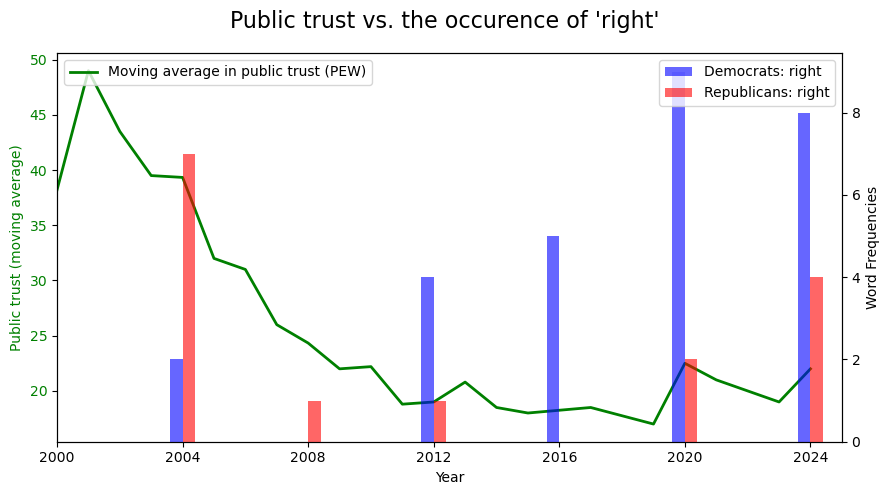

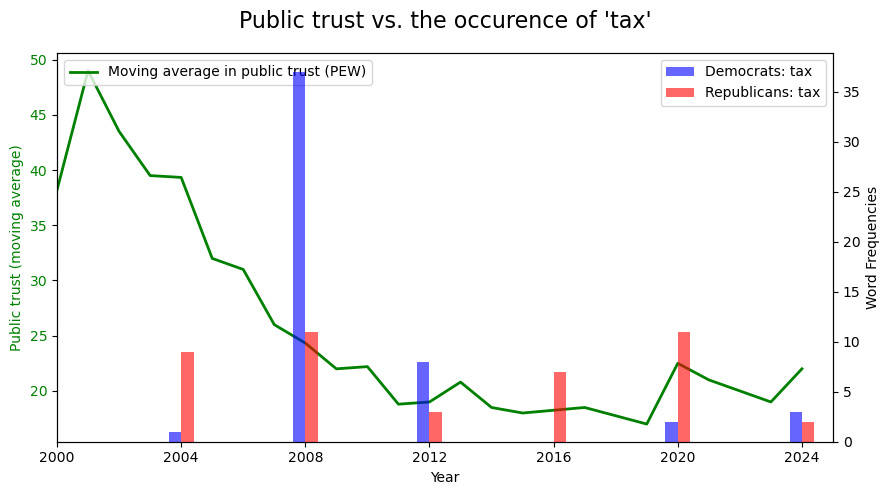

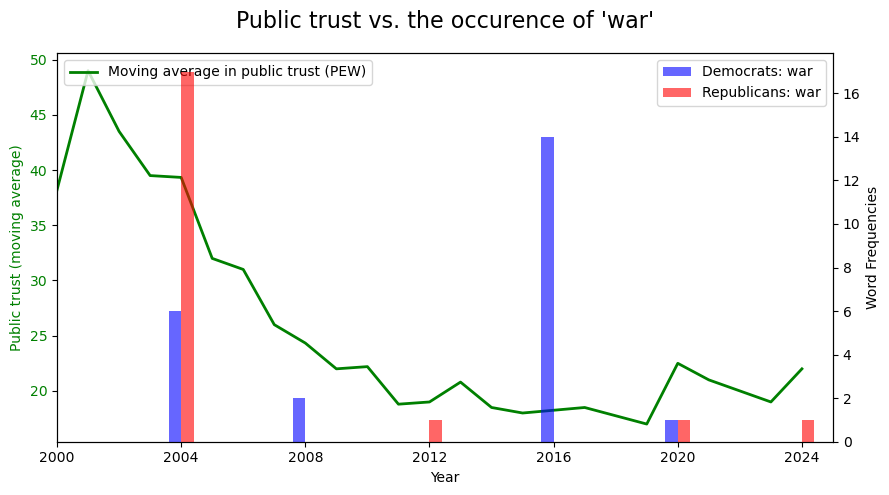

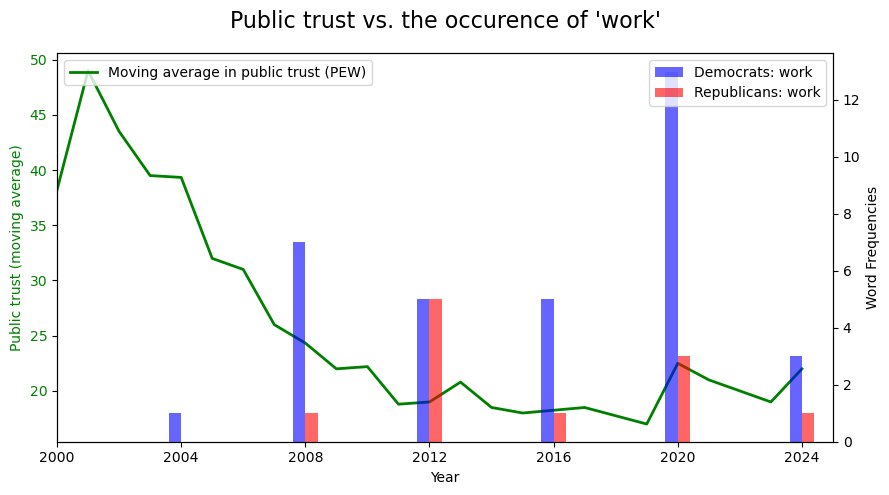

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

list_words = ["american","border","country","crisis","cut","economy","freedom","health","immigrant","iraq","job","migrant","protect","right","tax","war","work"]
save_directory = "/Users/inqsoncharoen/Documents/Election_Analysis/Figures/OverlaidPlots"

for search_word in list_words:
    graph_path = "/Users/inqsoncharoen/Documents/Election_Analysis/PEW_public_trust.csv"
    dems_path = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_dems.csv"
    repub_path = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_rep.csv"

    graph_df = pd.read_csv(graph_path)
    dems_df = pd.read_csv(dems_path)
    repub_df = pd.read_csv(repub_path)

    graph_df.head(), dems_df.head(), repub_df.head()

    graph_df = pd.read_csv(graph_path, delimiter=";")

    graph_df["Date"] = pd.to_datetime(graph_df["Date"], format="%m/%d/%Y")
    graph_df["Year"] = graph_df["Date"].dt.year
    graph_yearly = graph_df.groupby("Year", as_index=False)["Moving average"].mean()

    #sort word freq by year
    dems_df = dems_df.sort_values("Year")
    repub_df = repub_df.sort_values("Year")
    fig, ax1 = plt.subplots(figsize=(9, 5))

    #plot for public trust / graph data
    ax1.plot(graph_yearly["Year"], graph_yearly["Moving average"], color="green", label="Moving average in public trust (PEW)", linewidth=2)
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Public trust (moving average)", color="green")
    ax1.tick_params(axis="y", labelcolor="green")

    #make another y-axis for the word search
    ax2 = ax1.twinx()

    #first bar chart, second bar chart
    bar_width = 0.4
    ax2.bar(dems_df["Year"] - bar_width/2, dems_df["Frequency"], 
            color="blue", alpha=0.6, label=f"Democrats: {search_word}", width=bar_width)
    ax2.bar(repub_df["Year"] + bar_width/2, repub_df["Frequency"], 
            color="red", alpha=0.6, label=f"Republicans: {search_word}", width=bar_width)

    #set their y-axis
    ax2.set_ylabel("Word Frequencies", color="black")
    ax2.tick_params(axis="y", labelcolor="black")

    #crop into date limits (but data is already in that range)
    ax1.set_xlim(min(dems_df["Year"]) - 1, max(dems_df["Year"]) + 1) #pew one not exactly integer-ish
    ax2.set_xlim(min(dems_df["Year"]) - 1, max(dems_df["Year"]) + 1)

    desired_ticks = [2000, 2004, 2008, 2012, 2016, 2020, 2024] #this is to fix the axis having decimal values like in the first graph i texted you about
    ax1.set_xticks(desired_ticks)
    ax2.set_xticks(desired_ticks)

    fig.suptitle(f"Public trust vs. the occurence of '{search_word}'", fontsize=16)
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    os.makedirs(save_directory, exist_ok=True)
    plt.savefig(os.path.join(save_directory,f"{search_word}_public_trust"))
    plt.show()



### Economic graphs

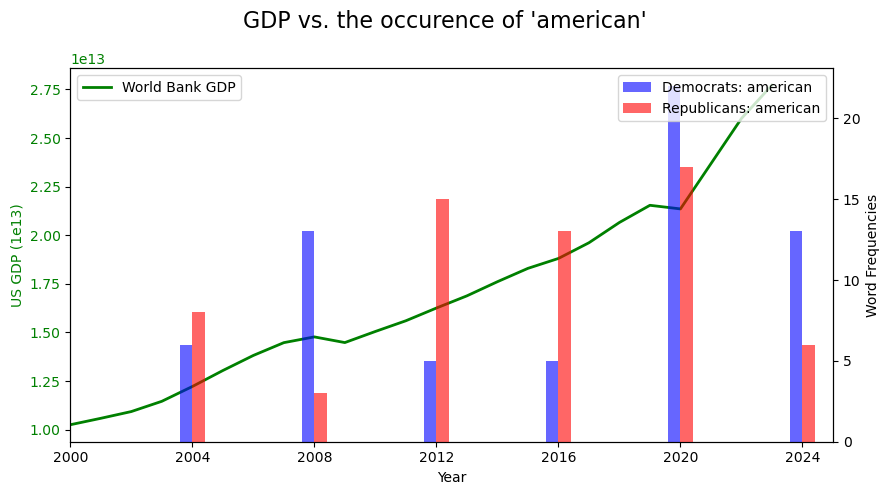

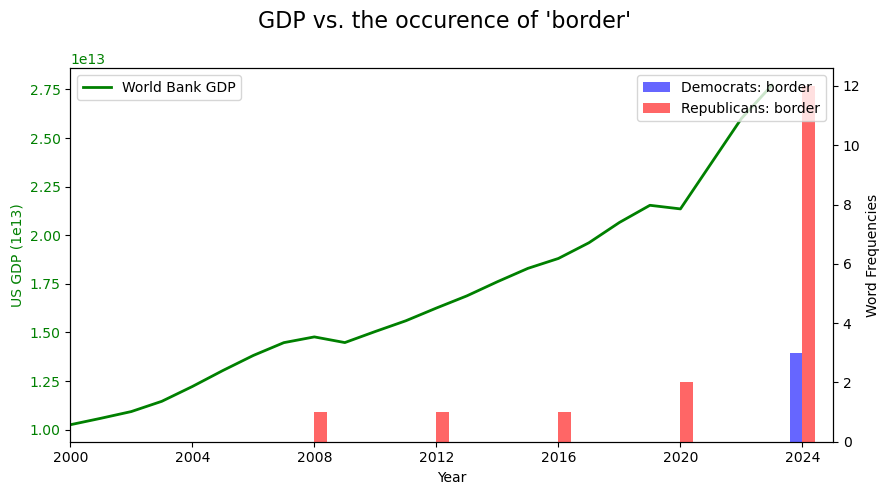

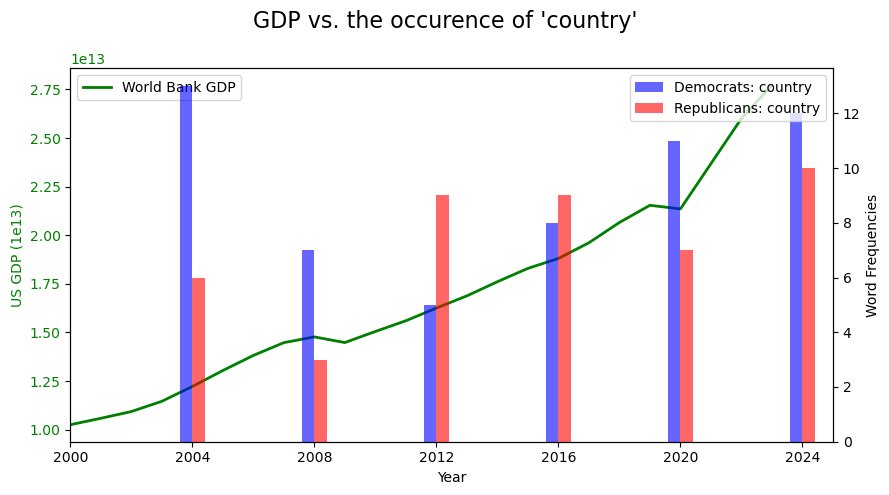

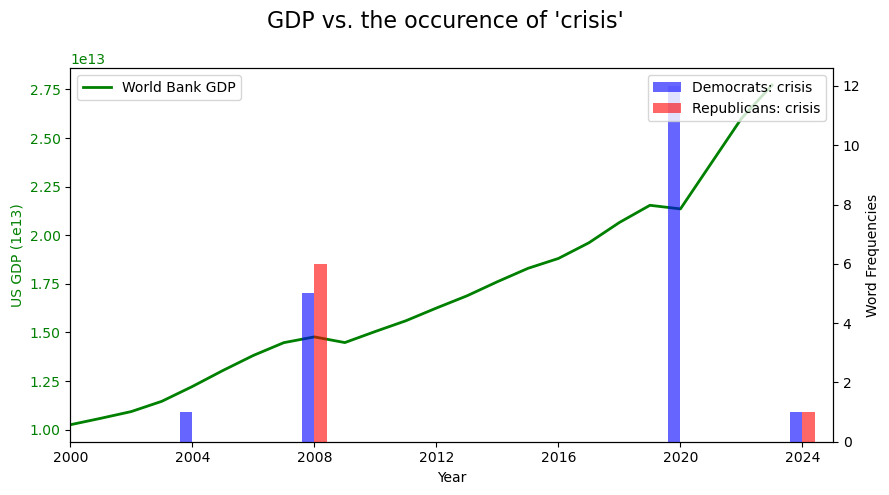

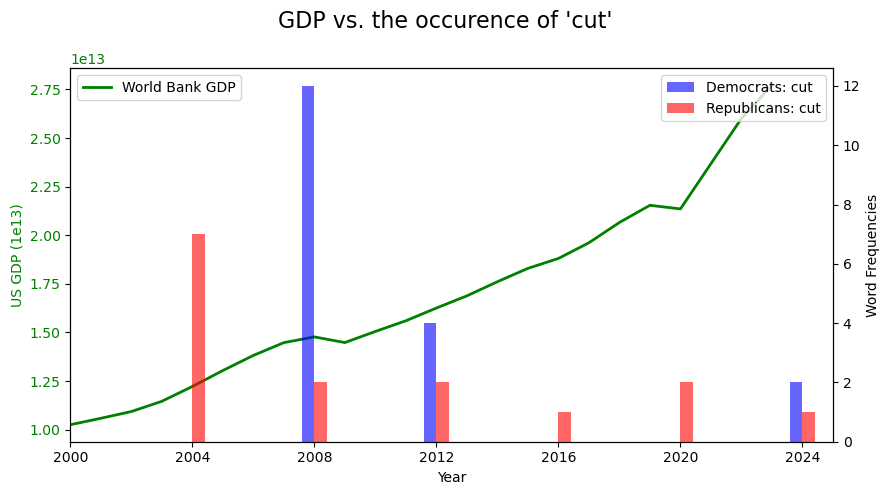

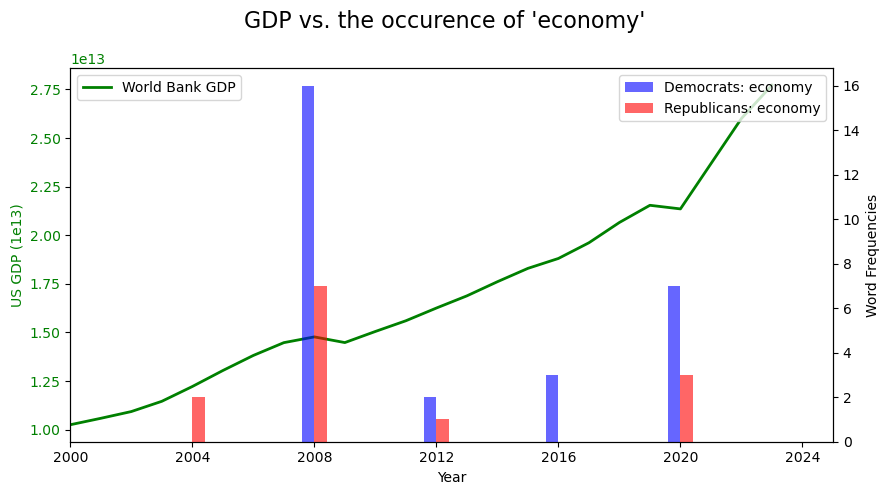

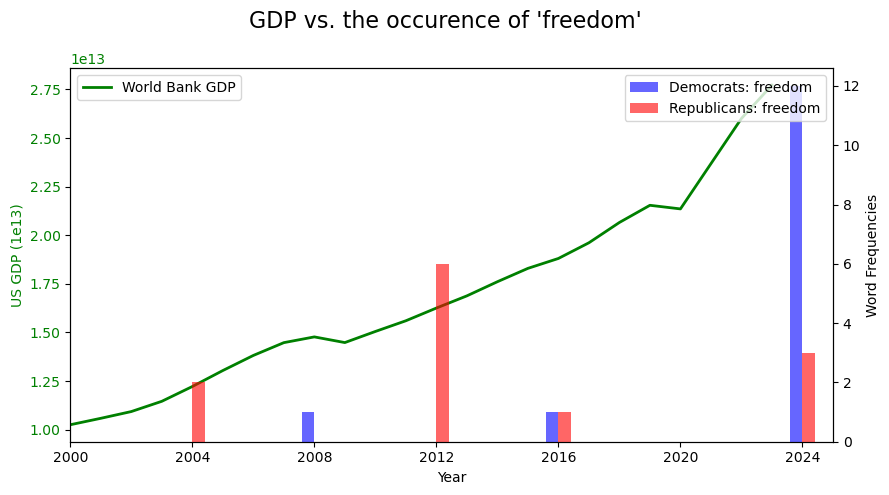

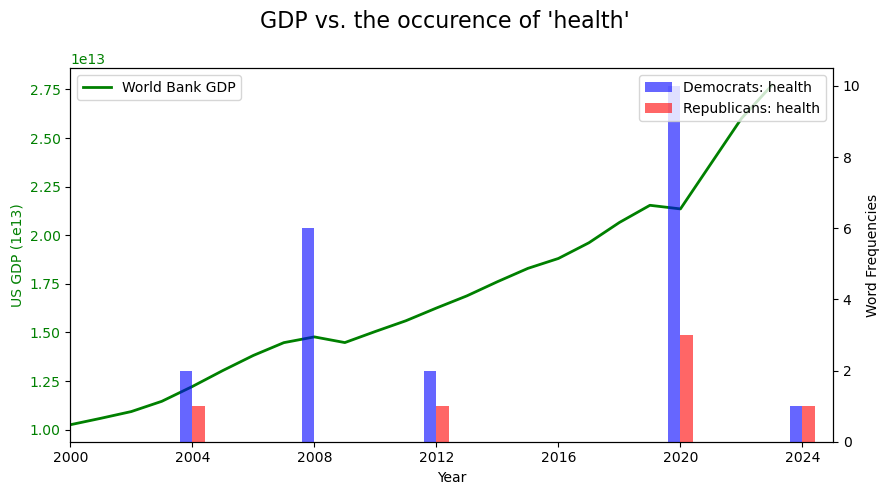

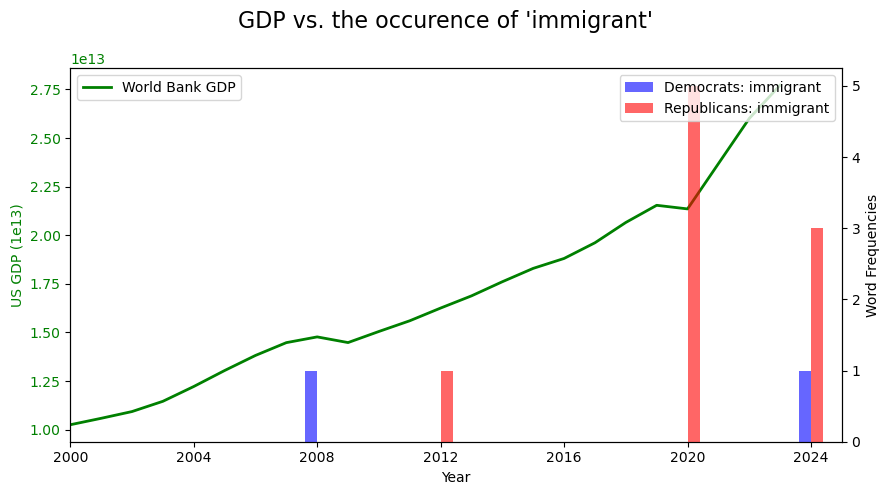

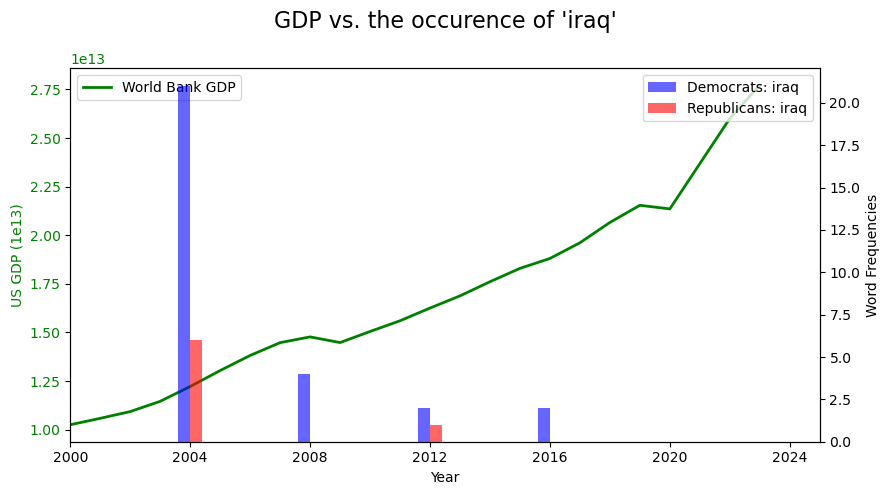

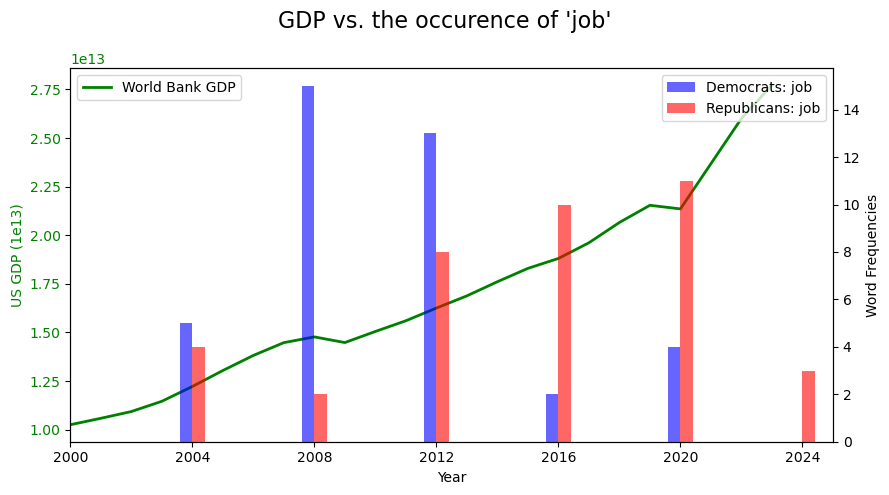

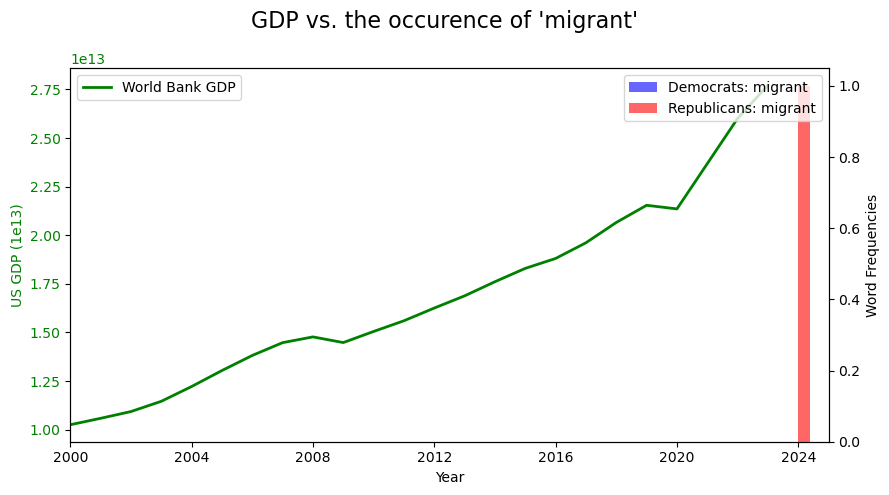

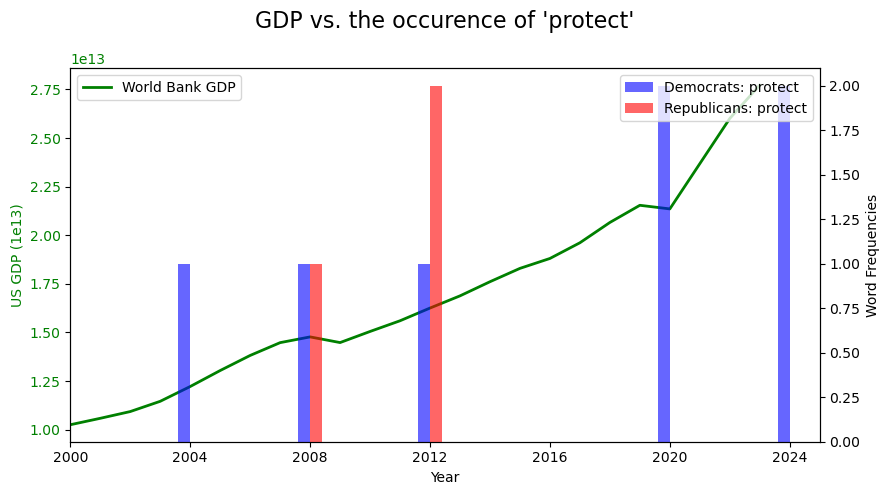

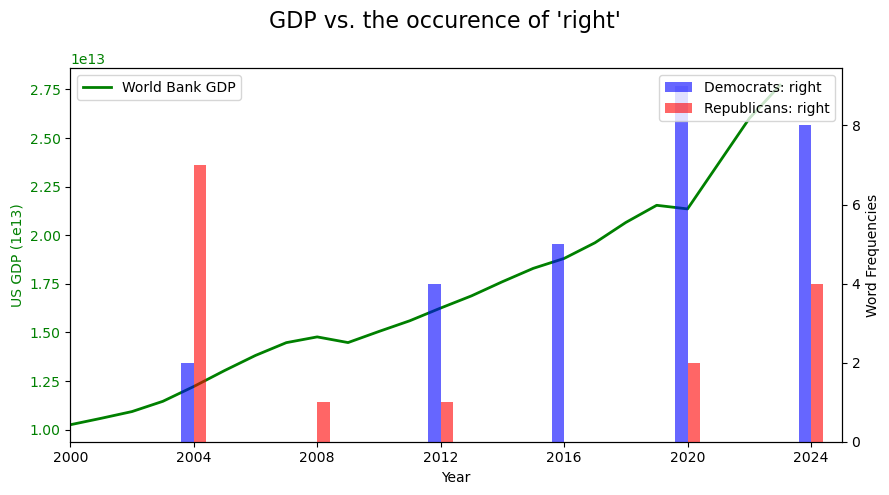

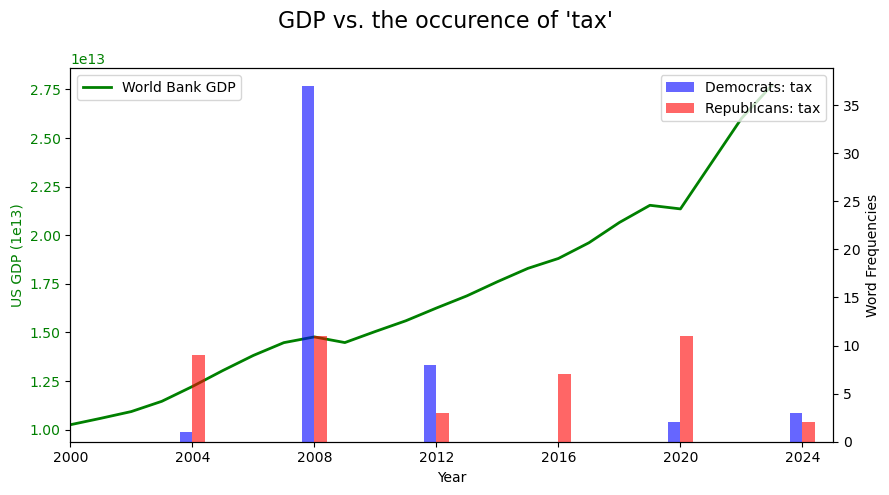

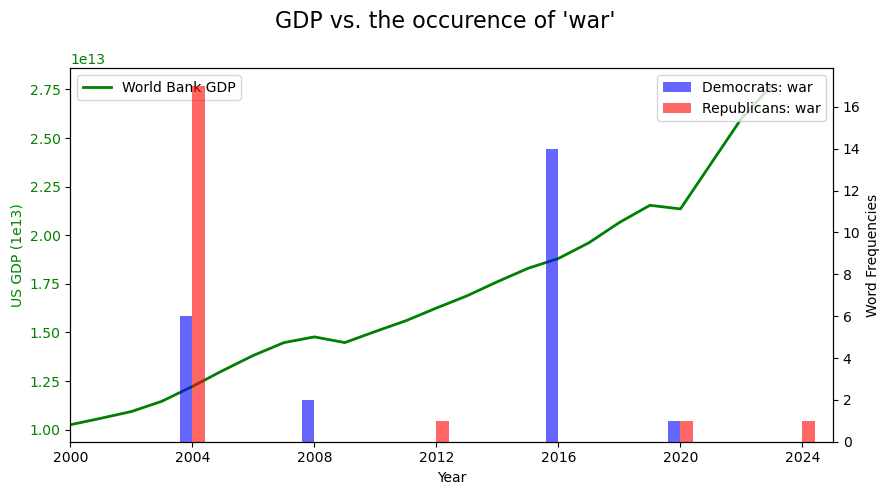

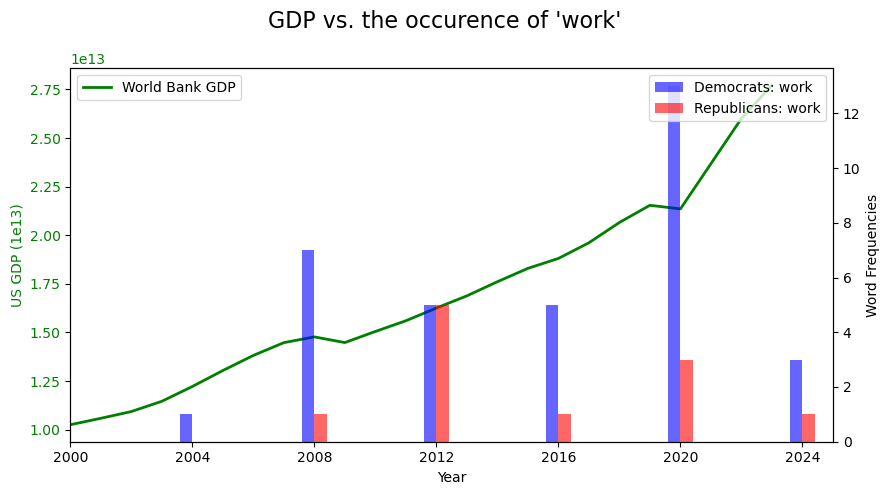

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

list_words = ["american","border","country","crisis","cut","economy","freedom","health","immigrant","iraq","job","migrant","protect","right","tax","war","work"]

for search_word in list_words:
    graph_path = "/Users/inqsoncharoen/Documents/Election_Analysis/WorldBankGDP_USA_Edited.csv"
    dems_path = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_dems.csv"
    repub_path = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_rep.csv"

    graph_df = pd.read_csv(graph_path)
    dems_df = pd.read_csv(dems_path)
    repub_df = pd.read_csv(repub_path)

    graph_df.head(), dems_df.head(), repub_df.head()

    graph_df = pd.read_csv(graph_path, delimiter=";")

   # graph_df["Date"] = pd.to_datetime(graph_df["Date"], format="%m/%d/%Y")
   # graph_df["Year"] = graph_df["Date"].dt.year
    graph_yearly = graph_df.groupby("Year", as_index=False)["GDP"].mean()

    #sort word freq by year
    dems_df = dems_df.sort_values("Year")
    repub_df = repub_df.sort_values("Year")
    fig, ax1 = plt.subplots(figsize=(9, 5))

    #plot for public trust / graph data
    ax1.plot(graph_yearly["Year"], graph_yearly["GDP"], color="green", label="World Bank GDP", linewidth=2)
    ax1.set_xlabel("Year")
    ax1.set_ylabel("US GDP (1e13)", color="green")
    ax1.tick_params(axis="y", labelcolor="green")

    #make another y-axis for the word search
    ax2 = ax1.twinx()

    #first bar chart, second bar chart
    bar_width = 0.4
    ax2.bar(dems_df["Year"] - bar_width/2, dems_df["Frequency"], 
            color="blue", alpha=0.6, label=f"Democrats: {search_word}", width=bar_width)
    ax2.bar(repub_df["Year"] + bar_width/2, repub_df["Frequency"], 
            color="red", alpha=0.6, label=f"Republicans: {search_word}", width=bar_width)

    #set their y-axis
    ax2.set_ylabel("Word Frequencies", color="black")
    ax2.tick_params(axis="y", labelcolor="black")

    #crop into date limits (but data is already in that range)
    ax1.set_xlim(min(dems_df["Year"]) - 1, max(dems_df["Year"]) + 1) #pew one not exactly integer-ish
    ax2.set_xlim(min(dems_df["Year"]) - 1, max(dems_df["Year"]) + 1)

    desired_ticks = [2000, 2004, 2008, 2012, 2016, 2020, 2024] #this is to fix the axis having decimal values like in the first graph i texted you about
    ax1.set_xticks(desired_ticks)
    ax2.set_xticks(desired_ticks)

    fig.suptitle(f"GDP vs. the occurence of '{search_word}'", fontsize=16)
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    os.makedirs(save_directory, exist_ok=True)
    plt.savefig(os.path.join(save_directory,f"{search_word}_GDP"))
    plt.show()



### Unemployment

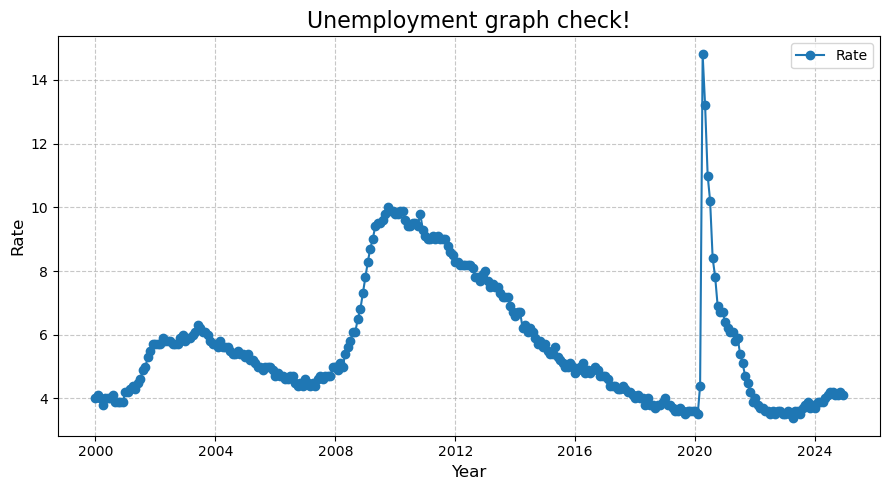

'/Users/inqsoncharoen/Documents/Election_Analysis/FinalBureauUnemployment.csv'

In [126]:
# first reorganize the data provided by the bureau
file_path = "/Users/inqsoncharoen/Documents/Election_Analysis/redostats.csv"
data = pd.read_csv(file_path, delimiter=";")

redo_data = data.melt(id_vars=["Year"], var_name="Month", value_name="Rate")

# convert year and month into reasonable format ugh
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
redo_data["Month"] = pd.Categorical(redo_data["Month"], categories=month_order, ordered=True)
redo_data = redo_data.sort_values(["Year", "Month"])
redo_data["Date"] = pd.to_datetime(redo_data["Year"].astype(str) + redo_data["Month"].astype(str), format="%Y%b")

#plot (to check it's consistent with what we see on the website)
plt.figure(figsize=(9, 5))
plt.plot(redo_data["Date"], redo_data["Rate"], marker="o", linestyle="-", label="Rate")
plt.title("Unemployment graph check!", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Rate", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()

output_path = "/Users/inqsoncharoen/Documents/Election_Analysis/FinalBureauUnemployment.csv"
redo_data[["Date", "Rate"]].to_csv(output_path, index=False)

plt.show()

output_path

# ask anastasa to look at how they come up with this rate


### Testing!

In [127]:
dems_df_convert = pd.read_csv("/Users/inqsoncharoen/Documents/Election_Analysis/war_freq_dems.csv")
#dems_df_convert["Date"] = pd.to_datetime(dems_df_convert["Year"])

dems_df_convert["Date"] = pd.to_datetime(dems_df_convert["Year"], format="%Y").dt.strftime("%Y-%m-%d")

dems_new_df = dems_df_convert[["Date", "Frequency"]].rename(columns={"Frequency": "Rate"})
dems_new_df


,Date,Rate
0,2004-01-01,6
1,2008-01-01,2
2,2012-01-01,0
3,2016-01-01,14
4,2020-01-01,1
5,2024-01-01,0


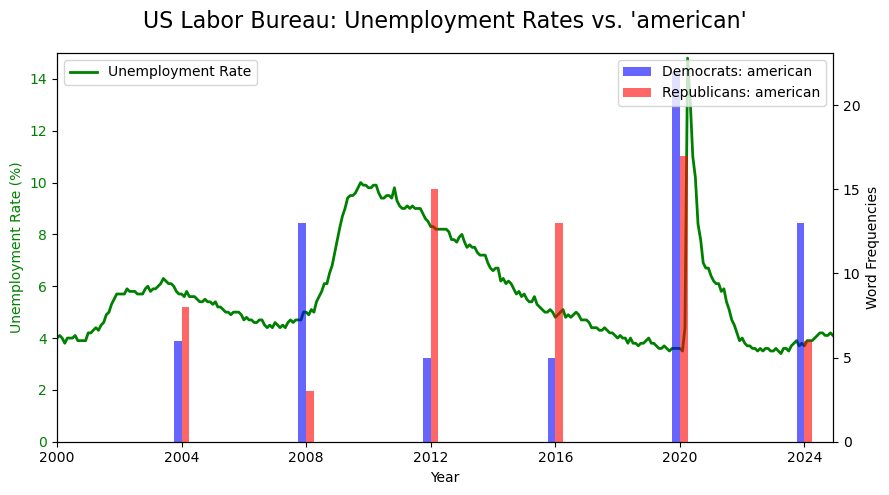

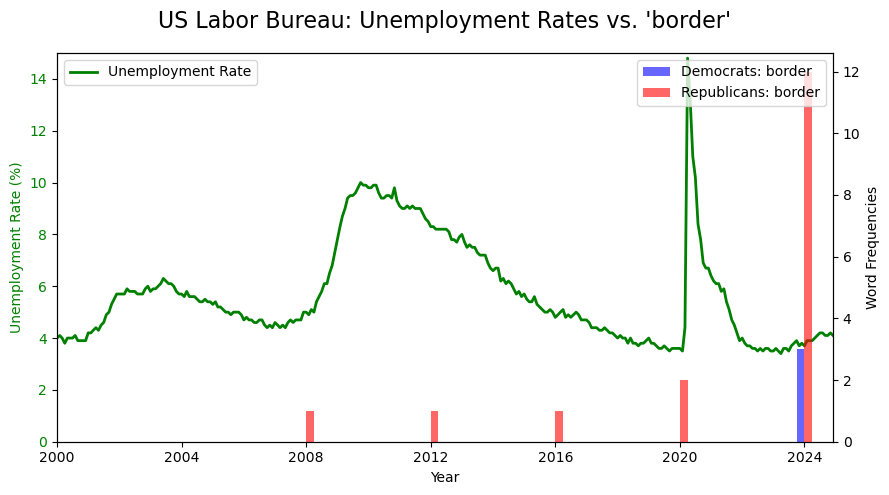

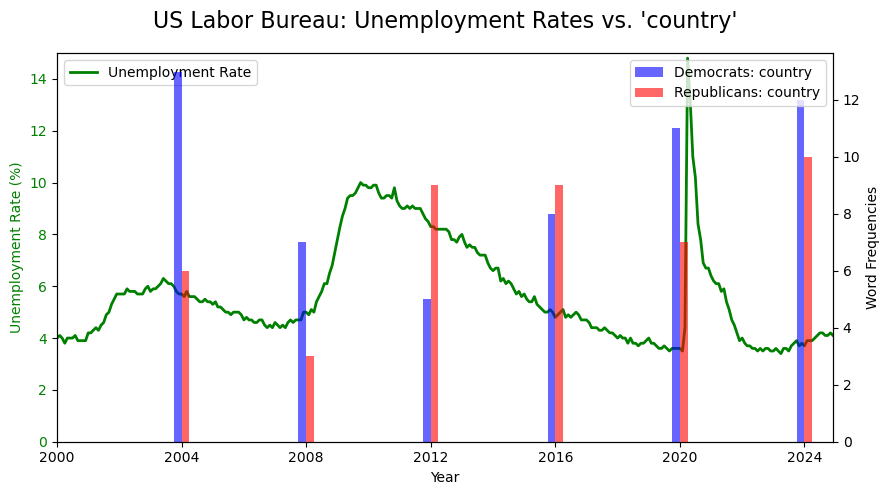

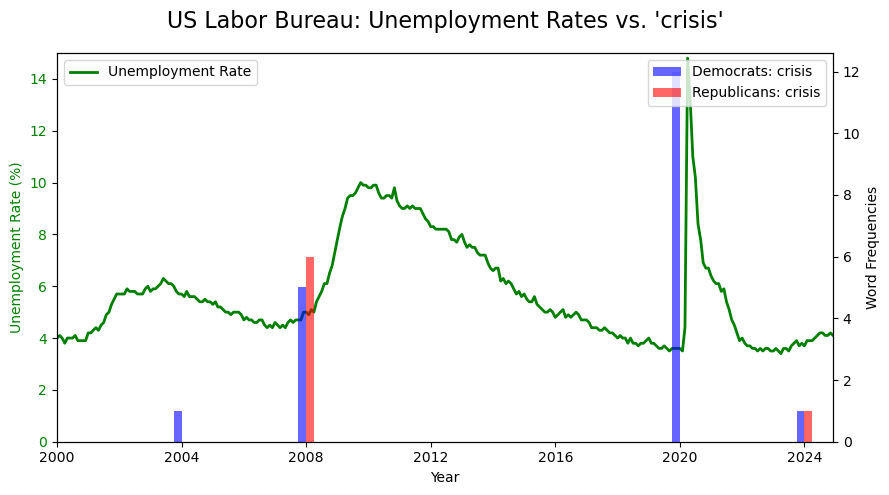

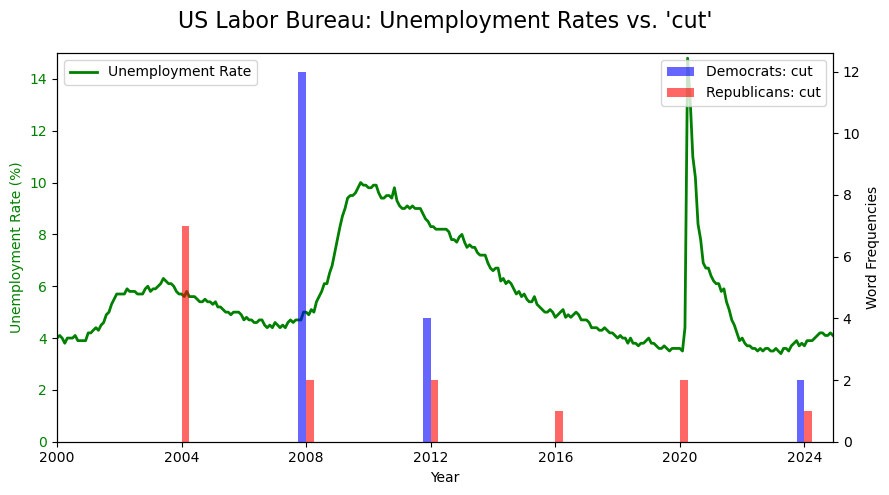

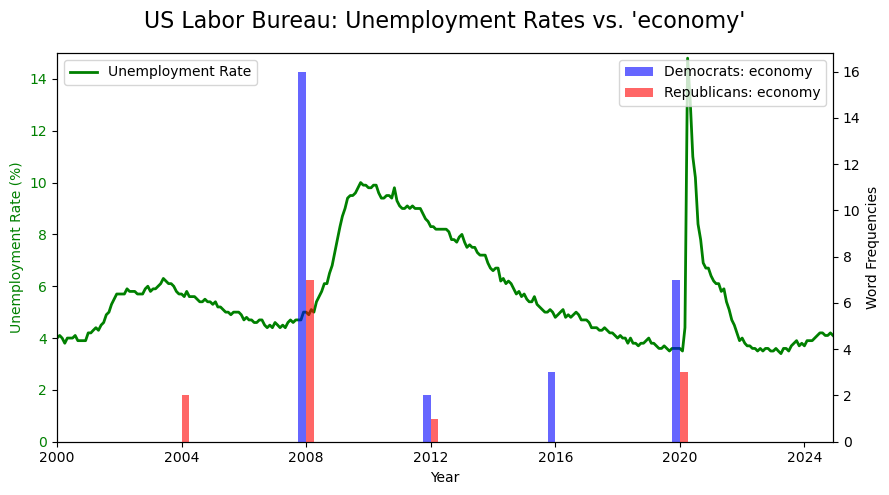

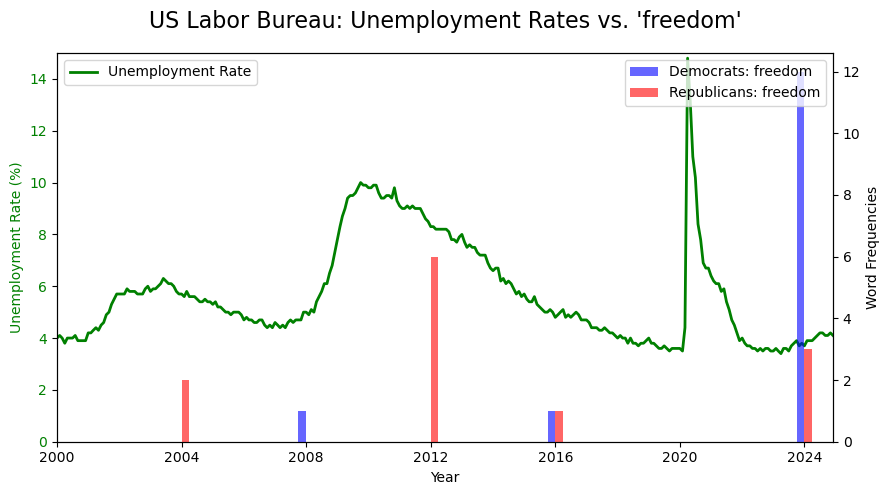

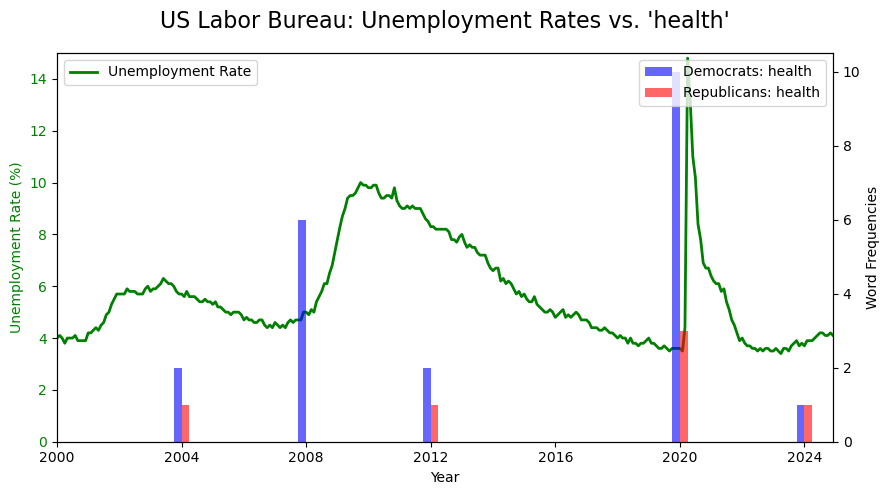

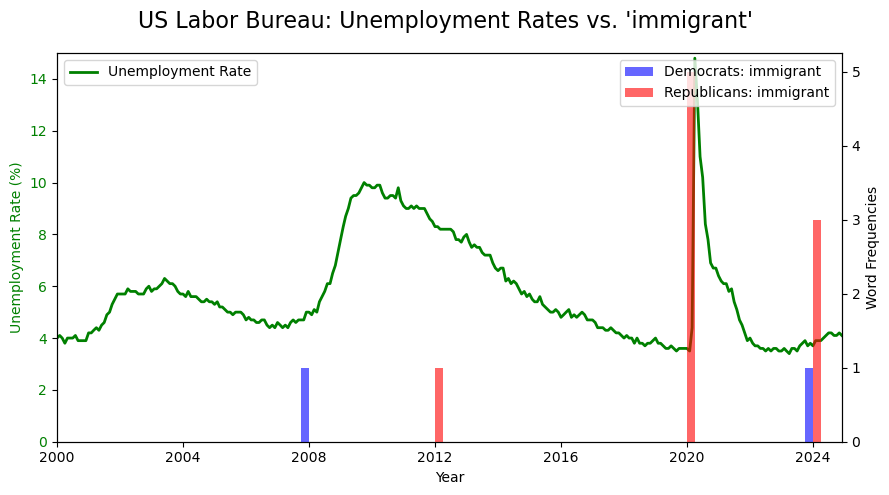

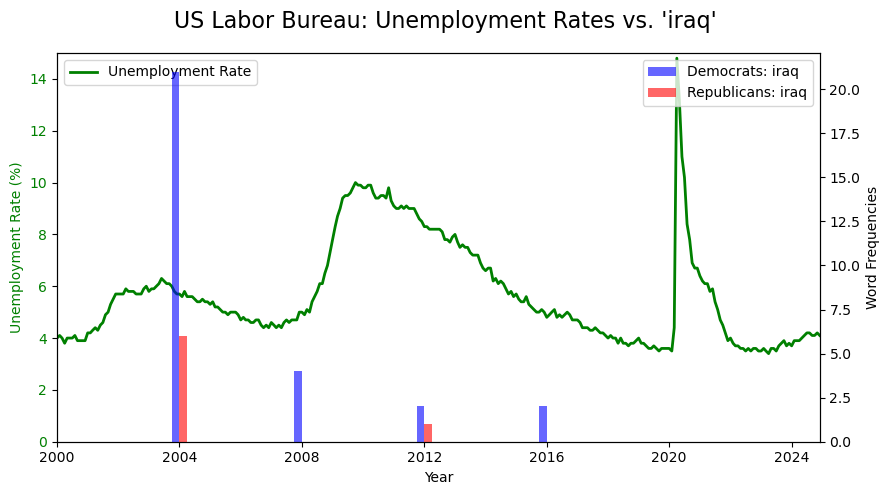

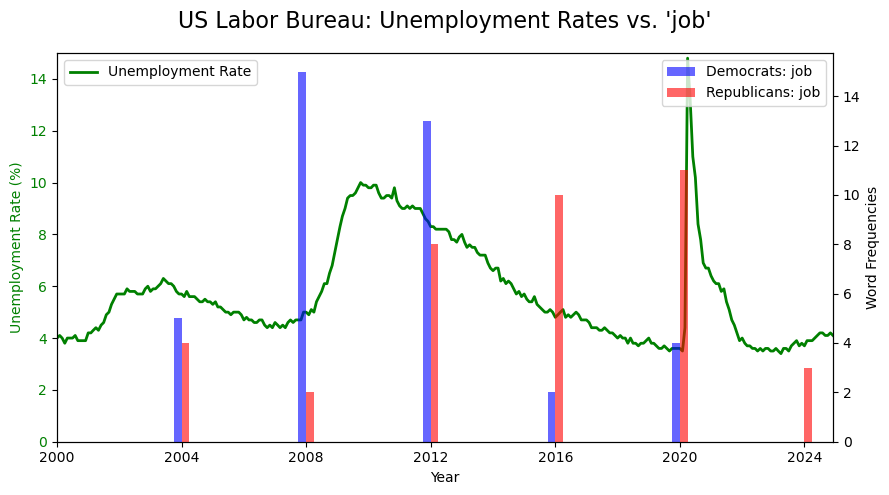

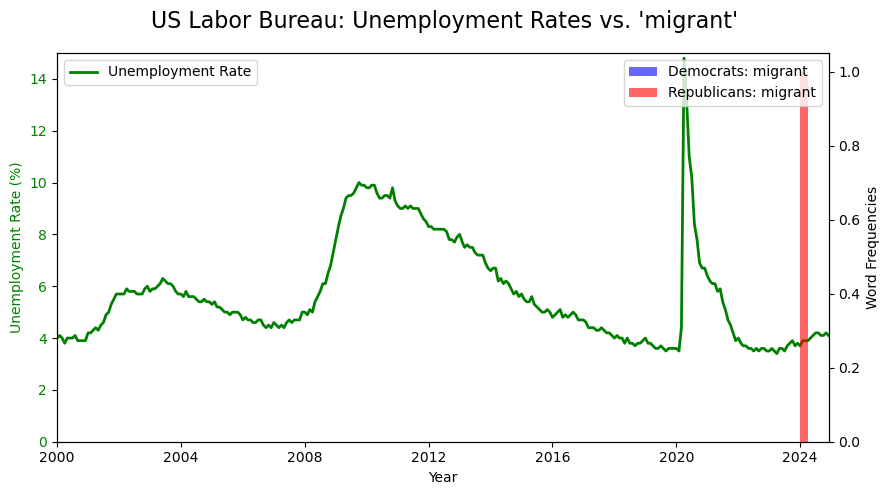

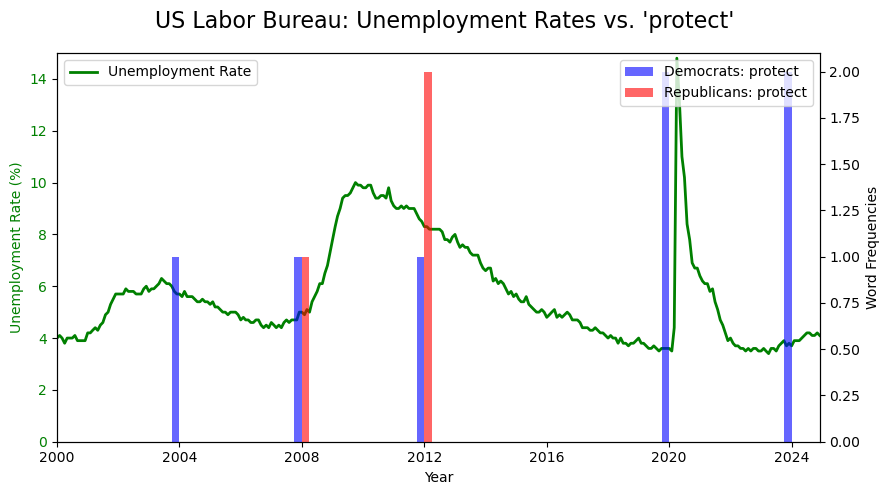

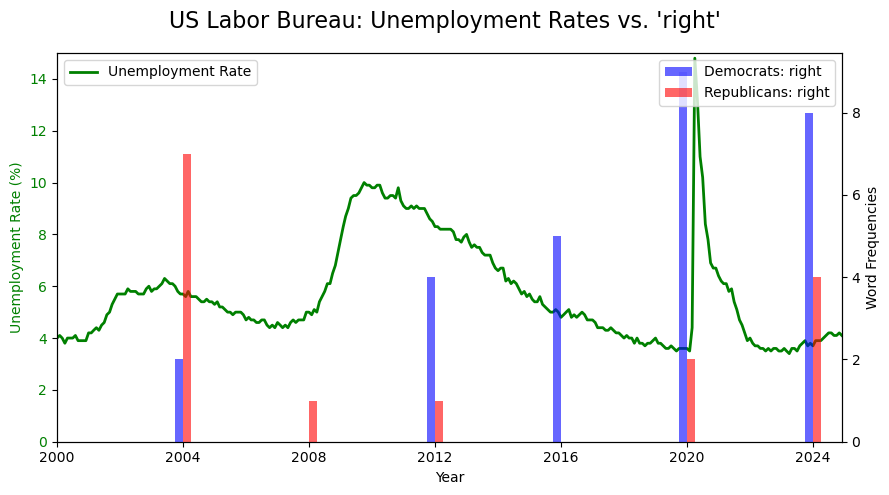

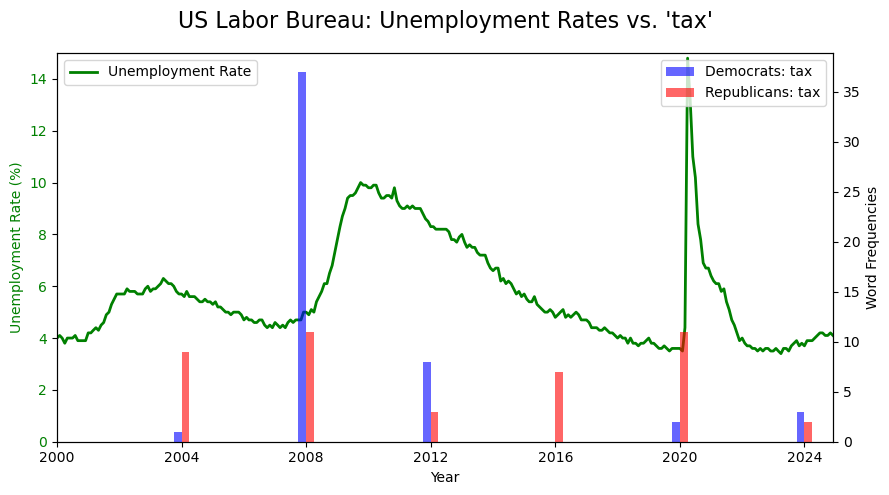

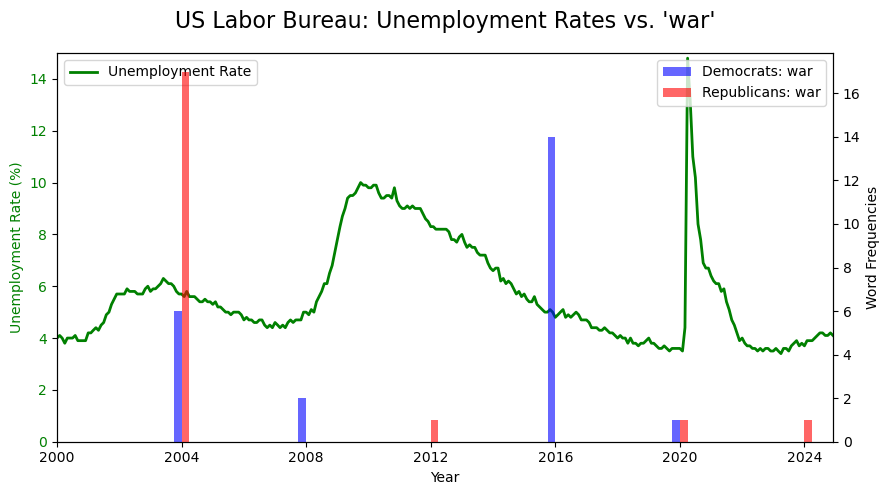

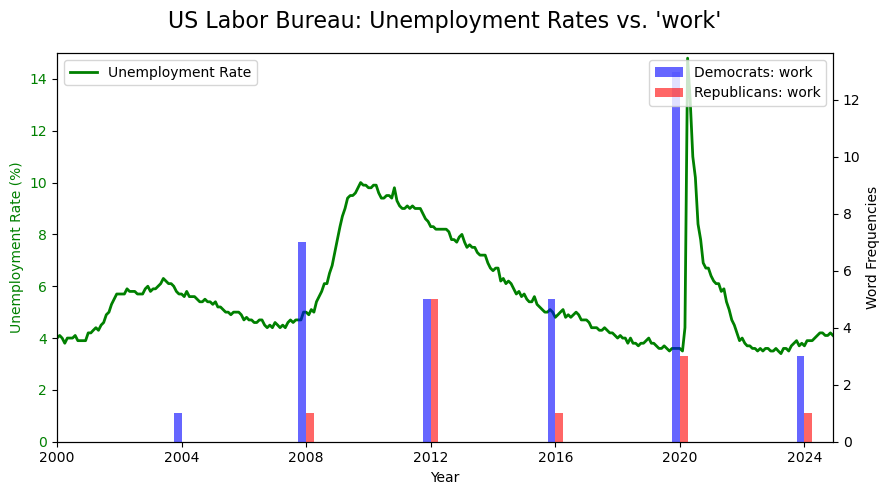

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

list_words = ["american","border","country","crisis","cut","economy","freedom","health","immigrant","iraq","job","migrant","protect","right","tax","war","work"]

for search_word in list_words:
    graph_path = "/Users/inqsoncharoen/Documents/Election_Analysis/FinalBureauUnemployment.csv"
    dems_path = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_dems.csv"
    repub_path = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_rep.csv"

    dems_df = pd.read_csv(dems_path)
    dems_df["Date"] = pd.to_datetime(dems_df["Year"], format="%Y", errors="coerce")
    dems_df = dems_df[["Date", "Frequency"]].rename(columns={"Frequency": "Rate"}).dropna()

    repub_df = pd.read_csv(repub_path)
    repub_df["Date"] = pd.to_datetime(repub_df["Year"], format="%Y", errors="coerce")
    repub_df = repub_df[["Date", "Frequency"]].rename(columns={"Frequency": "Rate"}).dropna()

    graph_df = pd.read_csv(graph_path, delimiter=";")
    graph_df["Date"] = pd.to_datetime(graph_df["Date"], format="%Y-%m-%d", errors="coerce")
    graph_df = graph_df.dropna()

    dems_df = dems_df.sort_values("Date")
    repub_df = repub_df.sort_values("Date")
    graph_df = graph_df.sort_values("Date")

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(graph_df["Date"], graph_df["Rate"], color="green", label="Unemployment Rate", linewidth=2)
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Unemployment Rate (%)", color="green")
    ax1.tick_params(axis="y", labelcolor="green")
    ax1.set_ylim(0, 15)

    ax2 = ax1.twinx()
    bar_width_days = 90 #approx bar width in days, add extra ax

    #plot dem freq as bar chart
    ax2.bar(dems_df["Date"] - pd.to_timedelta(bar_width_days // 2, unit="d"), dems_df["Rate"], 
            color="blue", alpha=0.6, label=f"Democrats: {search_word}", width=bar_width_days)

    ax2.bar(repub_df["Date"] + pd.to_timedelta(bar_width_days // 2, unit="d"), repub_df["Rate"], 
            color="red", alpha=0.6, label=f"Republicans: {search_word}", width=bar_width_days)

    ax2.set_ylabel("Word Frequencies", color="black")
    ax2.tick_params(axis="y", labelcolor="black")

    #set x-axis limits and ticks
    start_date = min(graph_df["Date"].min(), dems_df["Date"].min(), repub_df["Date"].min())
    end_date = max(graph_df["Date"].max(), dems_df["Date"].max(), repub_df["Date"].max())
    ax1.set_xlim(start_date, end_date)

    #set x-axis ticks to years only
    electoral_years = [2000, 2004, 2008, 2012, 2016, 2020, 2024]
    electoral_dates = pd.to_datetime([f"{year}-01-01" for year in electoral_years])
    ax1.set_xticks(electoral_dates)
    ax1.set_xticklabels([str(year) for year in electoral_years])

    fig.suptitle(f"US Labor Bureau: Unemployment Rates vs. '{search_word}'", fontsize=16)
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    os.makedirs(save_directory, exist_ok=True)
    plt.savefig(os.path.join(save_directory,f"{search_word}_unemployment"))
    plt.show()

